In [1]:
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DRIVE_URL = '/content/drive/MyDrive/radar_base_general_aleman_ramirez'
LOCAL_PATH = os.getcwd()

In [3]:
def detect_environment():
    try:
        ipython_env = str(get_ipython())

        if 'google.colab' in ipython_env:
            return "Google Colab"
        elif 'zmqshell' in ipython_env:
            return "Jupyter Notebook Local"
        else:
            return "Terminal interactiva de Python"
    except NameError:
        return "Script de Python estándar (.py)"


print(f"Entorno detectado: {detect_environment()}")

Entorno detectado: Jupyter Notebook Local


In [4]:
if detect_environment() != "Google Colab":
    BASE = LOCAL_PATH
else:
    BASE = DRIVE_URL
    from google.colab import drive

    drive.mount('/content/drive')

In [5]:
CLUSTER = os.path.join(BASE, "cluster")
WATER = os.path.join(BASE, "water_mask")

os.makedirs(WATER, exist_ok=True)

print("CLUSTER:", CLUSTER)
print("WATER:", WATER)

CLUSTER: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\cluster
WATER: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\water_mask


In [6]:
ruta_cluster_unf = os.path.join(CLUSTER, "cluster_unfiltered_k3.tiff")
ruta_cluster_flt = os.path.join(CLUSTER, "cluster_filtered_k3.tiff")

cluster_unf_3 = cv2.imread(ruta_cluster_unf, cv2.IMREAD_UNCHANGED)
cluster_flt_3 = cv2.imread(ruta_cluster_flt, cv2.IMREAD_UNCHANGED)

if len(cluster_unf_3.shape) == 3:
    cluster_unf_3 = cluster_unf_3[:, :, 0]

if len(cluster_flt_3.shape) == 3:
    cluster_flt_3 = cluster_flt_3[:, :, 0]

print("Valores únicos sin filtrar:", np.unique(cluster_unf_3))
print("Valores únicos filtrada:", np.unique(cluster_flt_3))
print("Shape:", cluster_unf_3.shape)

Valores únicos sin filtrar: [  0 127 255]
Valores únicos filtrada: [  0 127 255]
Shape: (2499, 2500)


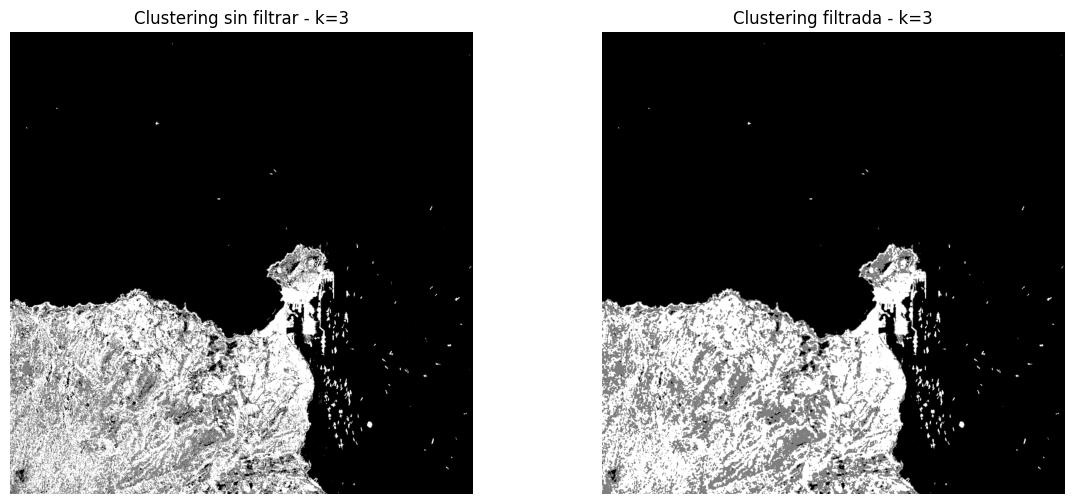

In [7]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cluster_unf_3, cmap="gray")
plt.title("Clustering sin filtrar - k=3")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cluster_flt_3, cmap="gray")
plt.title("Clustering filtrada - k=3")
plt.axis("off")

plt.show()

In [8]:
mask_water_unf = np.where(cluster_unf_3 == 0, 255, 0).astype(np.uint8)
mask_water_flt = np.where(cluster_flt_3 == 0, 255, 0).astype(np.uint8)

print("Máscaras creadas.")

Máscaras creadas.


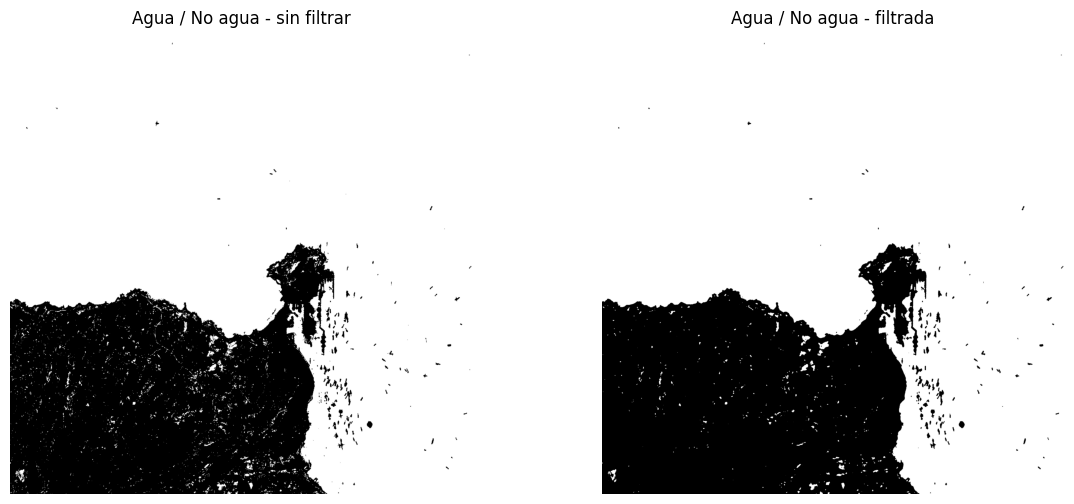

In [9]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(mask_water_unf, cmap="gray")
plt.title("Agua / No agua - sin filtrar")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_water_flt, cmap="gray")
plt.title("Agua / No agua - filtrada")
plt.axis("off")

plt.show()

In [10]:
def porcentaje_agua(mask):
    pixeles_agua = np.sum(mask == 255)
    total_pixeles = mask.size
    porcentaje = 100 * pixeles_agua / total_pixeles
    return pixeles_agua, total_pixeles, porcentaje


agua_unf, total_unf, pct_unf = porcentaje_agua(mask_water_unf)
agua_flt, total_flt, pct_flt = porcentaje_agua(mask_water_flt)

print("Sin filtrar")
print("  Píxeles agua:", agua_unf)
print("  Total píxeles:", total_unf)
print("  Porcentaje de agua:", pct_unf)

print("\nFiltrada")
print("  Píxeles agua:", agua_flt)
print("  Total píxeles:", total_flt)
print("  Porcentaje de agua:", pct_flt)

Sin filtrar
  Píxeles agua: 4598241
  Total píxeles: 6247500
  Porcentaje de agua: 73.60129651860744

Filtrada
  Píxeles agua: 4559601
  Total píxeles: 6247500
  Porcentaje de agua: 72.98280912364946


In [11]:
cv2.imwrite(os.path.join(WATER, "water_mask_unfiltered_k3.tiff"), mask_water_unf)
cv2.imwrite(os.path.join(WATER, "water_mask_filtered_k3.tiff"), mask_water_flt)

print("Máscaras guardadas en:", WATER)

Máscaras guardadas en: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\water_mask


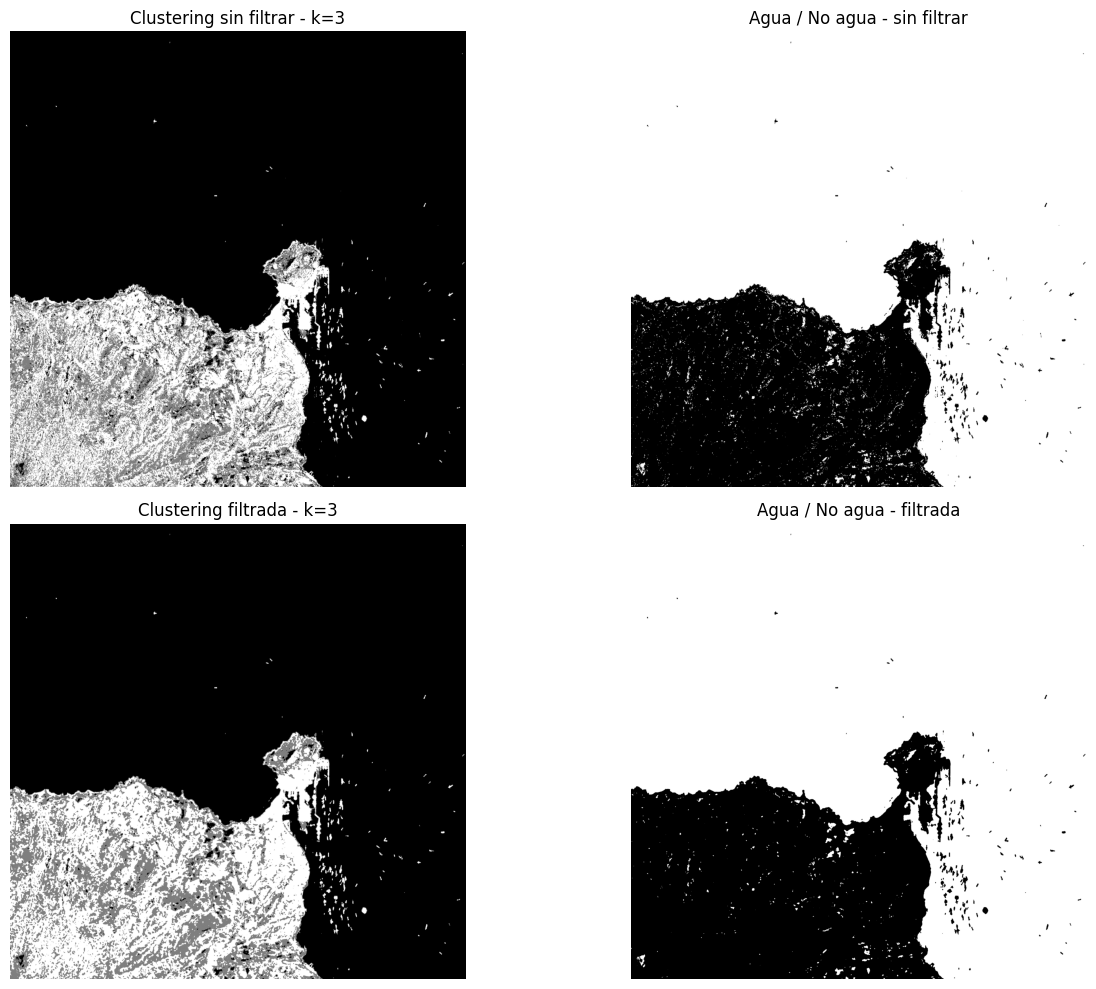

Figura comparativa guardada.


In [12]:
fig = plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(cluster_unf_3, cmap="gray")
plt.title("Clustering sin filtrar - k=3")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(mask_water_unf, cmap="gray")
plt.title("Agua / No agua - sin filtrar")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cluster_flt_3, cmap="gray")
plt.title("Clustering filtrada - k=3")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(mask_water_flt, cmap="gray")
plt.title("Agua / No agua - filtrada")
plt.axis("off")

plt.tight_layout()
fig.savefig(os.path.join(WATER, "comparacion_agua_no_agua_k3.png"), dpi=200, bbox_inches="tight")
plt.show()

print("Figura comparativa guardada.")